In [1]:
from ultralytics import YOLO
import os

In [2]:
model = YOLO(os.path.join("best_model","best.pt"))

In [3]:
images_val = os.path.join("training_data","images","val")
labels_val = os.path.join("training_data","labels","val")
os.listdir(images_val)[:10]

['33171bb8-BikesHelmets504.png',
 '3364dd79-BikesHelmets40.png',
 '338fd1c7-BikesHelmets157.png',
 '33fa5254-BikesHelmets20.png',
 '340b0d38-BikesHelmets655.png',
 '350fa141-BikesHelmets99.png',
 '35e2fe65-BikesHelmets370.png',
 '36146aac-BikesHelmets177.png',
 '37407806-BikesHelmets268.png',
 '375e5335-BikesHelmets185.png']

background


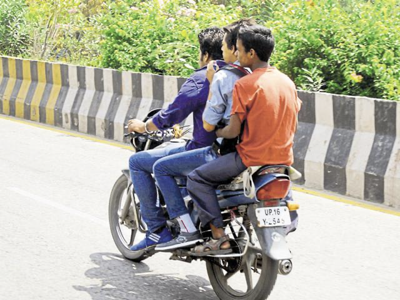


image 1/1 D:\AICW program\helmet_detection_new\training_data\images\val\33171bb8-BikesHelmets504.png: 480x640 (no detections), 206.2ms
Speed: 9.4ms preprocess, 206.2ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


In [4]:
sample = "33171bb8-BikesHelmets504"

with open(os.path.join(labels_val,sample+".txt")) as f:
    content = f.read()
    cls = content.split()
    
    if not cls:
        print("background")
    else:
        print(cls[0])

from IPython.display import Image, display

display(Image(filename = os.path.join(images_val, sample+".png")))
y_pred = model.predict(os.path.join(images_val,sample+".png"), conf = 0.1)

In [5]:
import cv2


# Load trained model
# Use the relative path to where the file is actually located
model = YOLO("D:/AICW program/helmet_detection_new/best_model/best.pt")  # Replace with your model path

# Open webcam
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

while True:
    success, frame = cap.read()

    if not success:
        print("Error: Could not read frame.")
        break

    # Run inference
    results = model.predict(frame, conf=0.4)

    for result in results:
        if len(result.boxes) == 0:
            continue

        for box in result.boxes:
            # Get class information
            cls_id = int(box.cls[0].item())
            detected = result.names[cls_id]
            confidence = box.conf[0].item()

            # Get bounding box coordinates
            xmin, ymin, xmax, ymax = map(int, box.xyxy[0].tolist())

            # Set color based on class
            if detected == "With Helmet":
                color = (0, 255, 0)      # Green
            elif detected == "Without Helmet":
                color = (0, 0, 255)      # Red
            else:
                color = (255, 255, 255)  # White (fallback)

            # Draw bounding box
            cv2.rectangle(frame, (xmin, ymin), (xmax, ymax), color, 2)

            # Draw label
            label = f"{detected} {confidence:.2f}"
            cv2.putText(
                frame,
                label,
                (xmin, ymin - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2
            )

    # Display output
    cv2.imshow("Helmet Detection", frame)

    # Press Q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
                


0: 480x640 (no detections), 68.8ms
Speed: 3.4ms preprocess, 68.8ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 52.3ms
Speed: 1.6ms preprocess, 52.3ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 50.3ms
Speed: 1.5ms preprocess, 50.3ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 55.6ms
Speed: 1.4ms preprocess, 55.6ms inference, 0.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 54.0ms
Speed: 1.3ms preprocess, 54.0ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 72.6ms
Speed: 1.5ms preprocess, 72.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 56.6ms
Speed: 1.3ms preprocess, 56.6ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 94.6ms
Speed: 2.0ms preprocess, 94.6ms i